# Retail Sales Forecasting & Inventory Optimization – EDA

This notebook covers **problem framing, SKU–store forecasting scope, feature analysis, stockout-censored demand handling, and visual exploration**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')
%matplotlib inline

## 1. Forecasting Scope & Problem Definition

**Forecasting Grain:** SKU × Store × Day

**Target Variable:** `qty_sold` (daily units sold)

**Objective:** Forecast item-level demand and convert forecasts into inventory decisions (ROP, Safety Stock, EOQ).

### Handling Stockout-Censored Demand
- Observed sales may be zero due to **stockouts**, not lack of demand.
- Rows with `stockout_flag = 1` are excluded during model training.
- This avoids underestimating true demand.

In [2]:
df = pd.read_csv('../data/retail_timeseries.csv', parse_dates=['date'], dayfirst=True)
df.head(15)

,date,store_id,item_id,qty_sold,on_promo,discount_pct,Price,stockout_flag
0,2022-01-01,S001,P0001,127,0,0,33.50,0
1,2022-01-01,S001,P0002,150,0,0,63.01,0
2,2022-01-01,S001,P0003,65,1,10,27.99,0
3,2022-01-01,S001,P0004,61,1,25,32.72,0
4,2022-01-01,S001,P0005,14,1,10,73.64,0
5,2022-01-01,S001,P0006,128,1,15,76.83,0
6,2022-01-01,S001,P0007,97,1,5,34.16,0
7,2022-01-01,S001,P0008,312,0,0,97.99,0
8,2022-01-01,S001,P0009,175,0,0,20.74,0
9,2022-01-01,S001,P0010,28,1,15,59.99,0


## 2. Dataset Schema Overview

**Key Columns:**
- `store_id`, `item_id`: SKU–Store identifiers
- `date`: transaction date
- `qty_sold`: units sold (forecast target)
- `on_promo`, `discount_pct`: promotion signals
- `stockout_flag`: stockout indicator

In [3]:
df.info()
print("\nMissing values:\n", df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           73100 non-null  datetime64[ns]
 1   store_id       73100 non-null  object        
 2   item_id        73100 non-null  object        
 3   qty_sold       73100 non-null  int64         
 4   on_promo       73100 non-null  int64         
 5   discount_pct   73100 non-null  int64         
 6   Price          73100 non-null  float64       
 7   stockout_flag  73100 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(4), object(2)
memory usage: 4.5+ MB

Missing values:
 date             0
store_id         0
item_id          0
qty_sold         0
on_promo         0
discount_pct     0
Price            0
stockout_flag    0
dtype: int64


In [4]:
df['qty_sold'].describe()

count    73100.000000
mean       132.446525
std        109.763073
min          0.000000
25%         44.000000
50%        103.000000
75%        199.000000
max        499.000000
Name: qty_sold, dtype: float64

## 3. SKU–Store Coverage

In [5]:
unique_combinations = df[['store_id','item_id']].drop_duplicates().shape[0]
print(f"Unique SKU-Store combinations: {unique_combinations}")

Unique SKU-Store combinations: 100


## 4. Sales Distribution

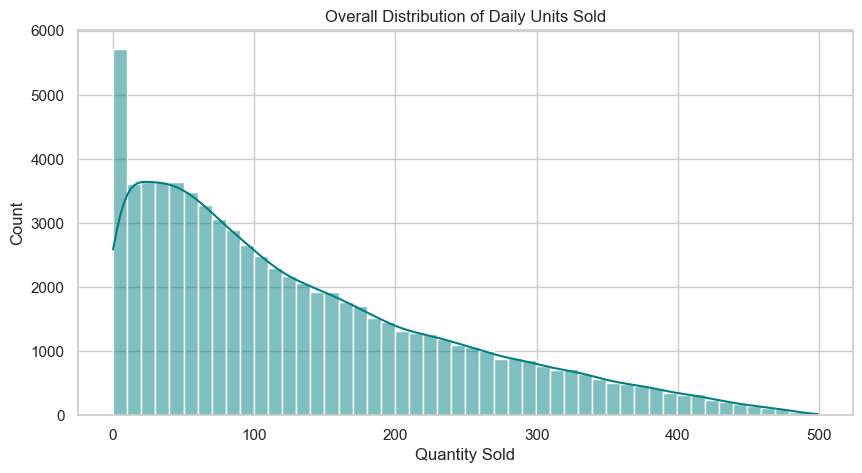

In [6]:
plt.figure(figsize=(10,5))
sns.histplot(df['qty_sold'], bins=50, kde=True, color='teal')
plt.title('Overall Distribution of Daily Units Sold')
plt.xlabel('Quantity Sold')
plt.show()

## 5. Daily Sales Trend (Sample SKU–Store)
Visualization of a single time-series to check for patterns.

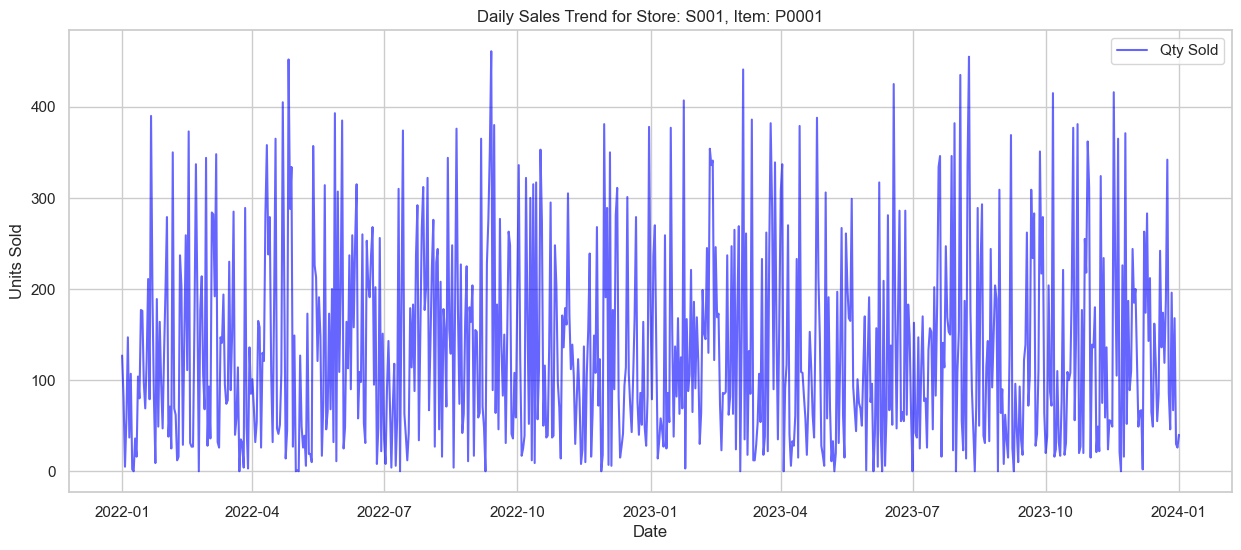

In [7]:
sample_store = df['store_id'].iloc[0]
sample_item = df['item_id'].iloc[0]
sample_df = df[(df['store_id'] == sample_store) & (df['item_id'] == sample_item)].sort_values('date')

plt.figure(figsize=(15,6))
plt.plot(sample_df['date'], sample_df['qty_sold'], label='Qty Sold', color='blue', alpha=0.6)
plt.title(f'Daily Sales Trend for Store: {sample_store}, Item: {sample_item}')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.show()

## 6. Correlation Analysis
Checking how Price and Promotions correlate with Sales.

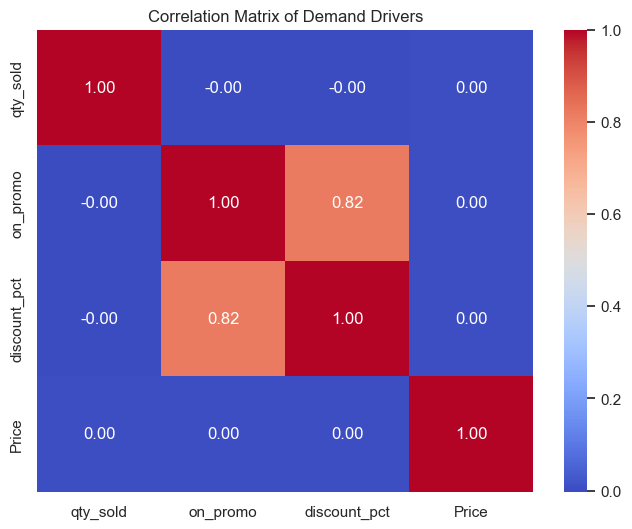

In [8]:
plt.figure(figsize=(8,6))
corr = df[['qty_sold', 'on_promo', 'discount_pct', 'Price']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Demand Drivers')
plt.show()